# Centrix vs Thermo Centroider — Real Spectrum Comparison

This notebook loads a single MS2 spectrum (scan 34790) from three mzML files:

| File | Description |
|------|-------------|
| `thermo-profile/…GPF-002.mzML` | Raw profile data from the Thermo Stellar |
| `thermo-centroid/…GPF-002.mzML` | Thermo's onboard centroider output |
| `thermo-profile/…GPF-002.centrix.mzML` | Centrix post-acquisition centroiding |

We focus on the **540–620 m/z** window and walk through:
1. The raw profile trace
2. How Centrix decomposes overlapping peaks using non-negative LASSO with Gaussian basis functions
3. A head-to-head comparison of Centrix vs Thermo centroids

**Instrument:** Thermo Stellar linear ion trap (radial ejection, ~0.5–0.7 Da FWHM).  
**MS2 profile grid:** 1/8 = 0.125 Th spacing, ~2 points per σ.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyteomics import mzml
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 120,
    "font.size": 10,
})

# --- File paths (relative to repo root) ---
DATA_DIR = Path("..") / "example-data"
PROFILE_FILE = DATA_DIR / "thermo-profile" / "2026-EISAI-DUNK-MoA-DIA-GPF-002.mzML"
CENTRIX_FILE = DATA_DIR / "thermo-profile" / "2026-EISAI-DUNK-MoA-DIA-GPF-002.centrix.mzML"
THERMO_FILE  = DATA_DIR / "thermo-centroid" / "2026-EISAI-DUNK-MoA-DIA-GPF-002.mzML"

SCAN_INDEX = 34789  # 0-based index for scan 34790
MZ_LO, MZ_HI = 540.0, 620.0

# --- Load the three spectra ---
def load_spectrum(path, index):
    reader = mzml.MzML(str(path))
    spec = reader.get_by_index(index)
    return spec["m/z array"], spec["intensity array"]

prof_mz, prof_int   = load_spectrum(PROFILE_FILE, SCAN_INDEX)
cx_mz,   cx_int     = load_spectrum(CENTRIX_FILE, SCAN_INDEX)
th_mz,   th_int     = load_spectrum(THERMO_FILE,  SCAN_INDEX)

# Crop to region of interest
def crop(mz, intensity, lo, hi):
    mask = (mz >= lo) & (mz <= hi)
    return mz[mask], intensity[mask]

prof_mz_r, prof_int_r = crop(prof_mz, prof_int, MZ_LO, MZ_HI)
cx_mz_r,   cx_int_r   = crop(cx_mz,   cx_int,   MZ_LO, MZ_HI)
th_mz_r,   th_int_r   = crop(th_mz,   th_int,   MZ_LO, MZ_HI)

print(f"Profile:  {len(prof_mz_r):>5} points  (step = {np.median(np.diff(prof_mz_r)):.4f} Th)")
print(f"Centrix:  {len(cx_mz_r):>5} centroids")
print(f"Thermo:   {len(th_mz_r):>5} centroids")

## 1. Raw Profile Trace (540–620 m/z)

The Thermo Stellar outputs profile-mode MS2 data on a **fixed grid of 0.125 Th** (8 points per Thomson).
With a typical peak σ ≈ 0.25 Th (FWHM ≈ 0.6 Da), that's only **~2 points per σ** — quite sparse.

Below is the raw profile for scan 34790 in the 540–620 m/z window.

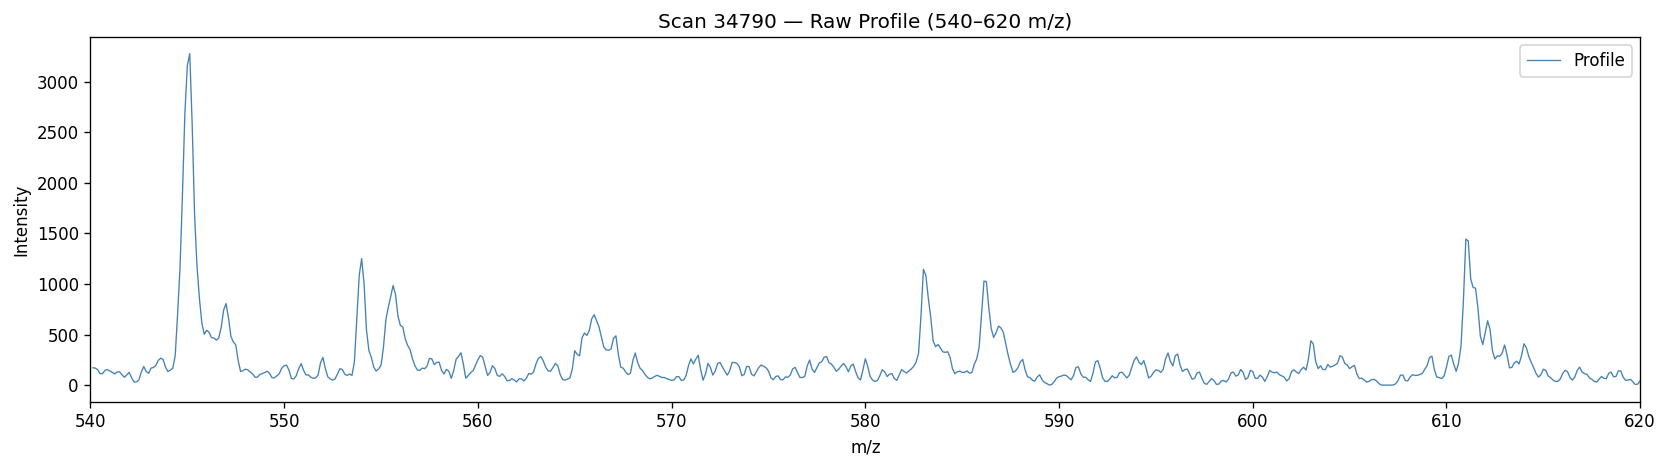

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prof_mz_r, prof_int_r, color="steelblue", linewidth=0.8, label="Profile")
ax.set_xlabel("m/z")
ax.set_ylabel("Intensity")
ax.set_title("Scan 34790 — Raw Profile (540–620 m/z)")
ax.set_xlim(MZ_LO, MZ_HI)
ax.legend()
plt.tight_layout()
plt.show()

## 2. The Centroiding Problem

The Thermo onboard centroider places roughly **one centroid per nominal mass unit**.
When two real signals fall within ~1 Da of each other, the centroider collapses them
into a single incorrect centroid — losing information.

Centrix addresses this by fitting a **non-negative LASSO** model with Gaussian basis
functions at sub-Da spacing, resolving overlapping peaks that the onboard algorithm cannot.

Let's overlay the Thermo and Centrix centroids on the profile to see the difference.

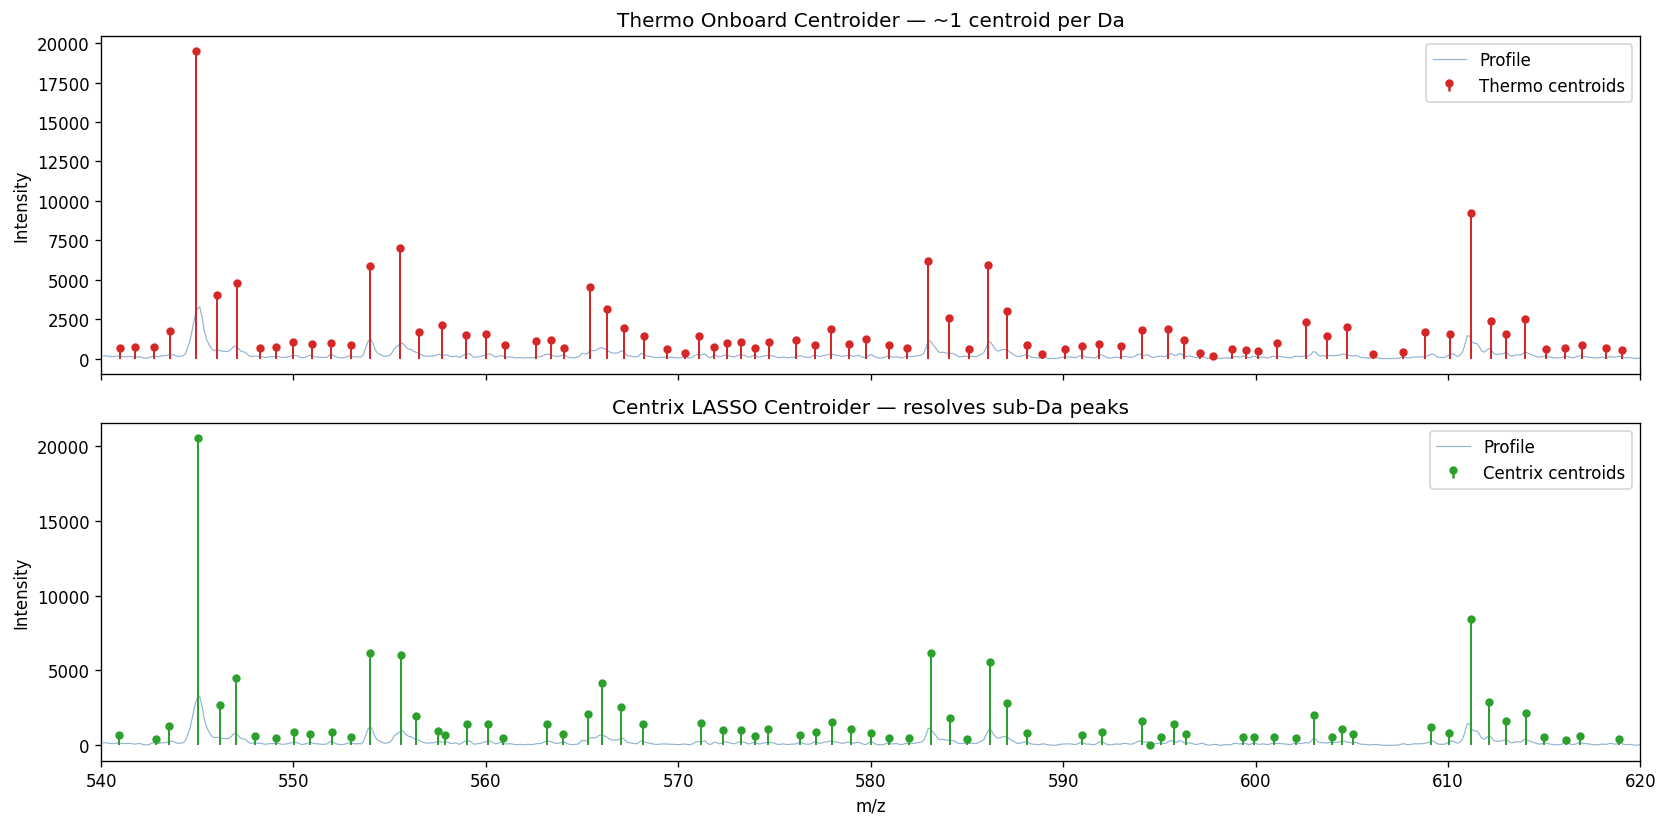

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- Top panel: Profile + Thermo centroids ---
ax = axes[0]
ax.plot(prof_mz_r, prof_int_r, color="steelblue", linewidth=0.7, alpha=0.6, label="Profile")
markerline, stemlines, baseline = ax.stem(
    th_mz_r, th_int_r, linefmt="C3-", markerfmt="C3o", basefmt=" ", label="Thermo centroids"
)
stemlines.set_linewidth(1.2)
markerline.set_markersize(4)
ax.set_ylabel("Intensity")
ax.set_title("Thermo Onboard Centroider — ~1 centroid per Da")
ax.legend(loc="upper right")

# --- Bottom panel: Profile + Centrix centroids ---
ax = axes[1]
ax.plot(prof_mz_r, prof_int_r, color="steelblue", linewidth=0.7, alpha=0.6, label="Profile")
markerline, stemlines, baseline = ax.stem(
    cx_mz_r, cx_int_r, linefmt="C2-", markerfmt="C2o", basefmt=" ", label="Centrix centroids"
)
stemlines.set_linewidth(1.2)
markerline.set_markersize(4)
ax.set_xlabel("m/z")
ax.set_ylabel("Intensity")
ax.set_title("Centrix LASSO Centroider — resolves sub-Da peaks")
ax.legend(loc="upper right")

for a in axes:
    a.set_xlim(MZ_LO, MZ_HI)

plt.tight_layout()
plt.show()

## 3. Zoom In — Isotope Envelope Near 611 m/z

The region around **609–616 m/z** shows a classic isotope envelope where Centrix resolves
sub-Da features that the Thermo centroider merges. Let's zoom in and examine this closely.

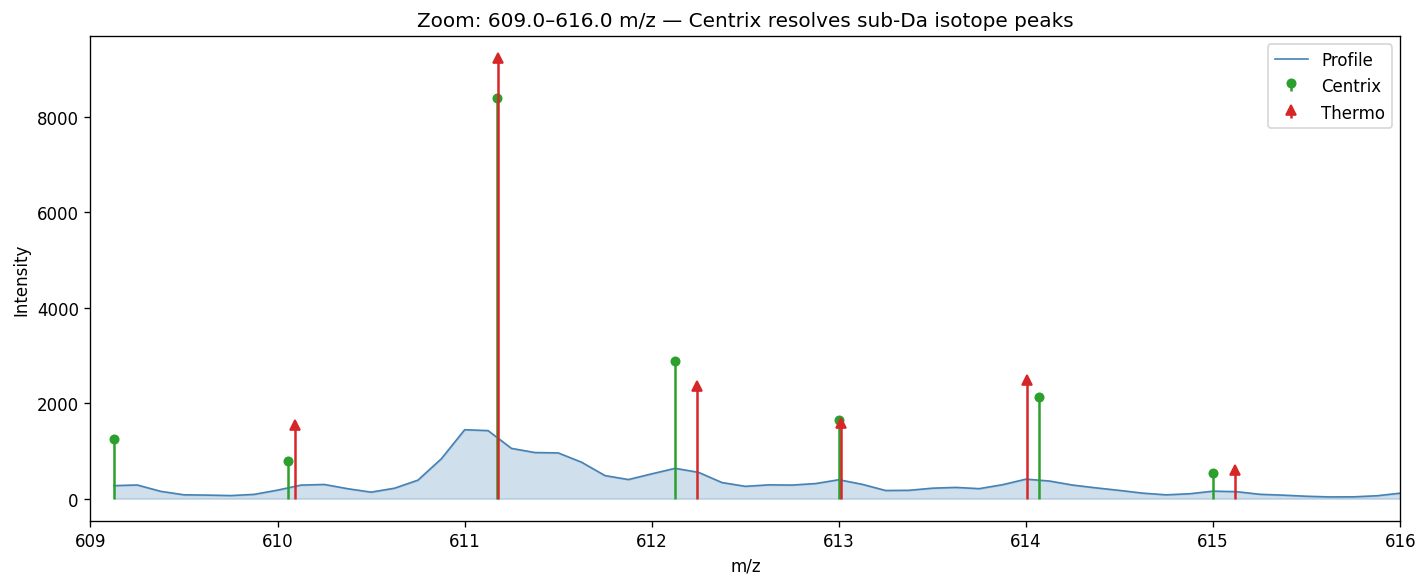


Thermo centroids in this window: 6
  610.0928  1548.0
  611.1772  9231.3
  612.2429  2353.8
  613.0117  1575.3
  614.0080  2492.0
  615.1188  590.2

Centrix centroids in this window: 7
  609.1250  1252.8
  610.0575  797.7
  611.1742  8399.0
  612.1250  2877.8
  613.0000  1647.9
  614.0689  2137.2
  615.0000  528.6


In [ ]:
ZOOM_LO, ZOOM_HI = 609.0, 616.0

p_mz, p_int = crop(prof_mz, prof_int, ZOOM_LO, ZOOM_HI)
c_mz, c_int = crop(cx_mz,   cx_int,   ZOOM_LO, ZOOM_HI)
t_mz, t_int = crop(th_mz,   th_int,   ZOOM_LO, ZOOM_HI)

fig, ax = plt.subplots(figsize=(12, 5))

# Profile as filled area
ax.fill_between(p_mz, p_int, alpha=0.25, color="steelblue")
ax.plot(p_mz, p_int, color="steelblue", linewidth=1.0, label="Profile", zorder=2)

# Centrix centroids
markerline, stemlines, baseline = ax.stem(
    c_mz, c_int, linefmt="C2-", markerfmt="C2o", basefmt=" ", label="Centrix"
)
stemlines.set_linewidth(1.5)
markerline.set_markersize(5)

# Thermo centroids
markerline, stemlines, baseline = ax.stem(
    t_mz, t_int, linefmt="C3-", markerfmt="C3^", basefmt=" ", label="Thermo"
)
stemlines.set_linewidth(1.5)
markerline.set_markersize(6)

ax.set_xlabel("m/z")
ax.set_ylabel("Intensity")
ax.set_title(f"Zoom: {ZOOM_LO}–{ZOOM_HI} m/z — Centrix resolves sub-Da isotope peaks")
ax.legend()
ax.set_xlim(ZOOM_LO, ZOOM_HI)
plt.tight_layout()
plt.show()

print(f"\nThermo centroids in this window: {len(t_mz)}")
for m, i in zip(t_mz, t_int):
    print(f"  {m:.4f}  {i:.1f}")

print(f"\nCentrix centroids in this window: {len(c_mz)}")
for m, i in zip(c_mz, c_int):
    print(f"  {m:.4f}  {i:.1f}")

## 4. How Centrix Works — Step by Step

Now let's walk through the Centrix algorithm on a single region of this spectrum to see
how it decomposes overlapping peaks.

### Step 4a: Noise Estimation

Centrix estimates noise from the **full spectrum** (all ~10,400 points for MS2), where
the majority of points are at the noise floor. This is critical — computing noise on a
small window with many signal peaks would overestimate the noise and over-regularize the LASSO.

- **Baseline** ≈ 10th percentile of all intensities
- **Noise σ** ≈ IQR / 1.349 (robust Gaussian σ estimator)
- **Detection threshold** = baseline + `signal_threshold_sigma` × noise σ

$$\hat{\sigma}_{\text{noise}} = \frac{Q_{75} - Q_{25}}{1.349}$$

Full spectrum:         10,400 points
Baseline (P10):        0.00
Estimated noise σ:     88.14
Detection threshold:   132.21  (baseline + 1.5σ)
LASSO λ:               440.72  (5.0 × noise)


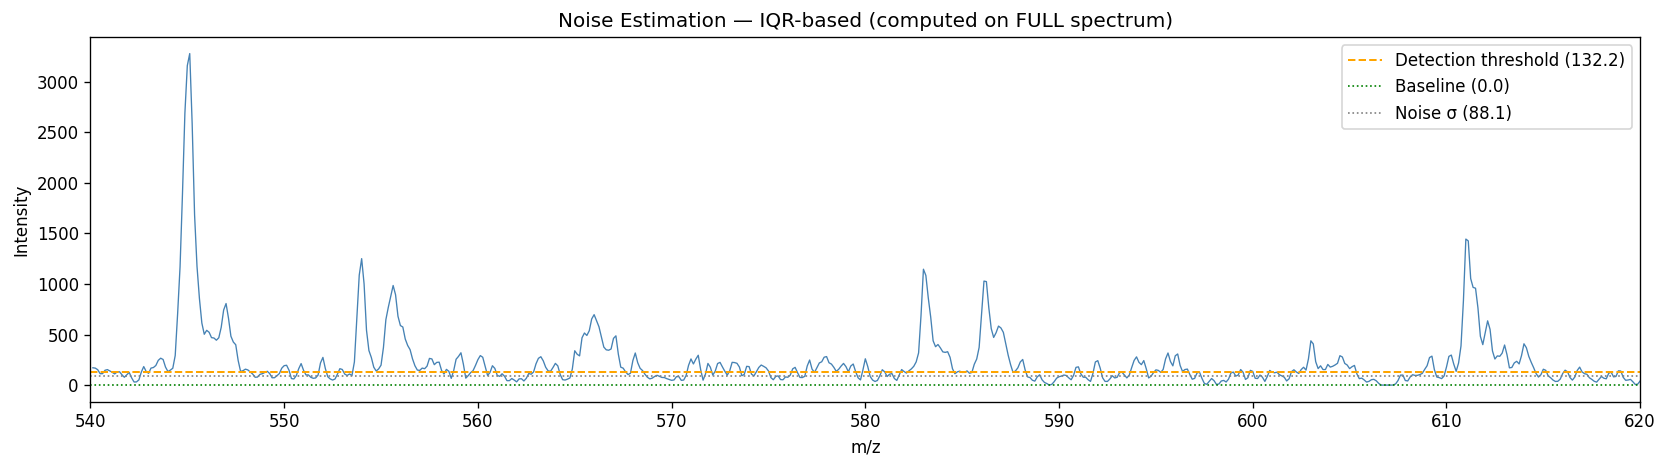

In [ ]:
# --- Centrix algorithm parameters (matching --lambda-factor 2 --signal-threshold-sigma 1.5) ---
SIGMA = 0.25         # Gaussian σ in Th (typical for Stellar MS2; ~0.6 Da FWHM)
GRID_SPACING = 0.125 # Profile grid spacing (1/8 Th for MS2)
LAMBDA_FACTOR = 5.0  # λ = lambda_factor × noise
SIGNAL_THRESHOLD_SIGMA = 1.5
NOISE_WINDOW_DA = 20.0
MERGE_GAP_POINTS = 2
EXTENSION_POINTS = 3

def rough_noise_estimate(intensities):
    """
    Noise estimate from the FULL spectrum, matching Centrix noise.rs.

    Uses the full intensity array (not a cropped window) because most of the
    ~10,400 MS2 data points are at the noise floor. Computing noise on a small
    signal-rich window would massively overestimate noise.
    """
    sorted_int = np.sort(np.abs(intensities))
    n = len(sorted_int)
    baseline = max(sorted_int[n // 10], 0.0)  # 10th percentile
    q25 = sorted_int[n // 4]
    q75 = sorted_int[n * 3 // 4]
    noise_sigma = max((q75 - q25) / 1.349, baseline * 0.1, 1.0)
    return baseline, noise_sigma

# Noise from the FULL spectrum, not just the 540-620 crop
baseline, noise_sigma = rough_noise_estimate(prof_int)
threshold = baseline + SIGNAL_THRESHOLD_SIGMA * noise_sigma
lam = LAMBDA_FACTOR * noise_sigma

print(f"Full spectrum:         {len(prof_int):,} points")
print(f"Baseline (P10):        {baseline:.2f}")
print(f"Estimated noise σ:     {noise_sigma:.2f}")
print(f"Detection threshold:   {threshold:.2f}  (baseline + {SIGNAL_THRESHOLD_SIGMA}σ)")
print(f"LASSO λ:               {lam:.2f}  ({LAMBDA_FACTOR} × noise)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prof_mz_r, prof_int_r, color="steelblue", linewidth=0.8)
ax.axhline(threshold, color="orange", linestyle="--", linewidth=1.2, label=f"Detection threshold ({threshold:.1f})")
ax.axhline(baseline, color="green", linestyle=":", linewidth=1.0, label=f"Baseline ({baseline:.1f})")
ax.axhline(noise_sigma, color="gray", linestyle=":", linewidth=1.0, label=f"Noise σ ({noise_sigma:.1f})")
ax.set_xlabel("m/z")
ax.set_ylabel("Intensity")
ax.set_title("Noise Estimation — IQR-based (computed on FULL spectrum)")
ax.set_xlim(MZ_LO, MZ_HI)
ax.legend()
plt.tight_layout()
plt.show()

### Step 4b: Signal Region Detection

Centrix scans the profile and groups consecutive above-threshold points into **signal regions**,
with a merge gap (default 2 points = 0.25 Th) to join nearby peaks. Each region is then
extended by 3 points on each side to capture the tails of Gaussian peaks.

Let's detect regions in the 540–620 m/z window.

Found 32 signal regions in 540–620 m/z



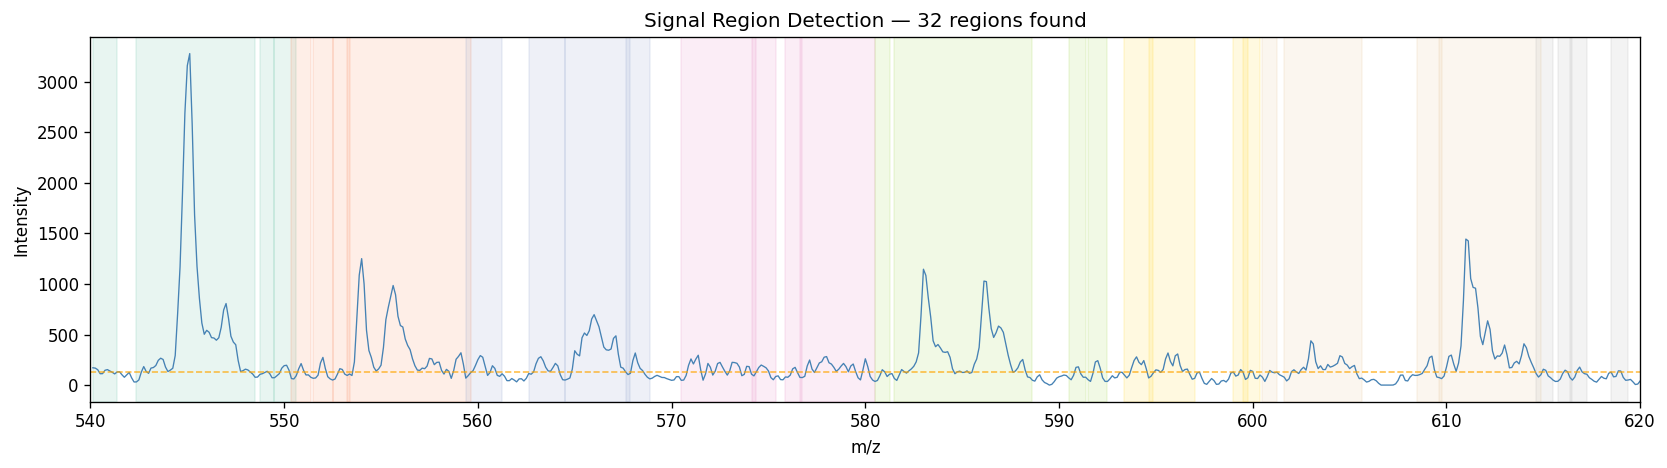

  Region  0: 540.12 – 541.37  (11 pts, 1.25 Th)
  Region  1: 542.37 – 548.50  (50 pts, 6.12 Th)
  Region  2: 548.75 – 549.50  (7 pts, 0.75 Th)
  Region  3: 549.50 – 550.62  (10 pts, 1.12 Th)
  Region  4: 550.37 – 551.37  (9 pts, 1.00 Th)
  Region  5: 551.50 – 552.50  (9 pts, 1.00 Th)
  Region  6: 552.50 – 553.37  (8 pts, 0.87 Th)
  Region  7: 553.25 – 559.62  (52 pts, 6.37 Th)
  Region  8: 559.37 – 561.25  (16 pts, 1.87 Th)
  Region  9: 562.62 – 564.50  (16 pts, 1.87 Th)
  Region 10: 564.50 – 567.87  (28 pts, 3.37 Th)
  Region 11: 567.62 – 568.87  (11 pts, 1.25 Th)
  Region 12: 570.50 – 574.37  (32 pts, 3.87 Th)
  Region 13: 574.12 – 575.37  (11 pts, 1.25 Th)
  Region 14: 575.87 – 576.75  (8 pts, 0.87 Th)
  Region 15: 576.62 – 580.50  (32 pts, 3.87 Th)
  Region 16: 580.50 – 581.25  (7 pts, 0.75 Th)
  Region 17: 581.50 – 588.62  (58 pts, 7.12 Th)
  Region 18: 590.50 – 591.37  (8 pts, 0.87 Th)
  Region 19: 591.50 – 592.50  (9 pts, 1.00 Th)
  Region 20: 593.37 – 594.87  (13 pts, 1.50 Th)


In [ ]:
def detect_regions(mz, intensity, threshold, merge_gap=MERGE_GAP_POINTS,
                   extension=EXTENSION_POINTS, min_width=3):
    """Detect signal regions above threshold, matching Centrix signal.rs."""
    n = len(mz)
    above = intensity > threshold
    regions = []
    i = 0
    while i < n:
        if above[i]:
            start = i
            while i < n and above[i]:
                i += 1
            end = i  # exclusive
            regions.append((start, end))
        else:
            i += 1

    # Merge regions separated by <= merge_gap points
    merged = []
    for s, e in regions:
        if merged and s - merged[-1][1] <= merge_gap:
            merged[-1] = (merged[-1][0], e)
        else:
            merged.append((s, e))

    # Extend and enforce minimum width
    final = []
    for s, e in merged:
        s = max(0, s - extension)
        e = min(n, e + extension)
        if e - s >= min_width:
            final.append((s, e))
    return final

regions = detect_regions(prof_mz_r, prof_int_r, threshold)
print(f"Found {len(regions)} signal regions in 540–620 m/z\n")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prof_mz_r, prof_int_r, color="steelblue", linewidth=0.8)
ax.axhline(threshold, color="orange", linestyle="--", linewidth=1.0, alpha=0.7)

colors = plt.cm.Set2(np.linspace(0, 1, max(len(regions), 8)))
for idx, (s, e) in enumerate(regions):
    ax.axvspan(prof_mz_r[s], prof_mz_r[e - 1], alpha=0.15, color=colors[idx % len(colors)])

ax.set_xlabel("m/z")
ax.set_ylabel("Intensity")
ax.set_title(f"Signal Region Detection — {len(regions)} regions found")
ax.set_xlim(MZ_LO, MZ_HI)
plt.tight_layout()
plt.show()

# Print region summary
for i, (s, e) in enumerate(regions):
    width = prof_mz_r[e-1] - prof_mz_r[s]
    print(f"  Region {i:2d}: {prof_mz_r[s]:.2f} – {prof_mz_r[e-1]:.2f}  ({e-s} pts, {width:.2f} Th)")

### Step 4c: Gaussian Basis Matrix & LASSO Decomposition

For each signal region, Centrix:
1. Places a **Gaussian basis function** (σ = 0.25 Th) at every grid point within the region
2. Builds the design matrix **A** where each column is one basis Gaussian
3. Solves the **non-negative LASSO**: $\min_{\beta \geq 0} \frac{1}{2}\|y - A\beta\|^2 + \lambda\|\beta\|_1$
4. Non-zero β coefficients become centroid amplitudes; their grid positions become centroid m/z values

The Gram matrix $G = A^T A$ is **Toeplitz** on a uniform grid — only one row is needed:

$$G[k] = \frac{\sigma\sqrt{\pi}}{h} \cdot \exp\!\left(\frac{-(k \cdot h)^2}{4\sigma^2}\right)$$

where $h$ is the grid spacing. Centrix uses this analytical formula rather than computing
$A^T A$ directly — it's exact for the interior and avoids O(n²) allocation.

Let's pick the region around **611 m/z** and run the LASSO decomposition.

In [ ]:
# Find the region containing ~611 m/z
target_mz = 611.0
demo_region = None
for s, e in regions:
    if prof_mz_r[s] <= target_mz <= prof_mz_r[e - 1]:
        demo_region = (s, e)
        break

if demo_region is None:
    # Fall back to nearest region
    for s, e in regions:
        if prof_mz_r[s] <= target_mz + 2:
            demo_region = (s, e)

s, e = demo_region
region_mz  = prof_mz_r[s:e]
region_int = prof_int_r[s:e]
n_pts = len(region_mz)
print(f"Demo region: {region_mz[0]:.2f} – {region_mz[-1]:.2f} m/z  ({n_pts} points)")

# Build Gaussian basis matrix A
# Each column is a Gaussian centered at grid_mz[j] evaluated at the data points
grid_mz = region_mz.copy()  # basis at every data point (matches Centrix)
n_basis = len(grid_mz)

A = np.zeros((n_pts, n_basis))
for j in range(n_basis):
    A[:, j] = np.exp(-0.5 * ((region_mz - grid_mz[j]) / SIGMA) ** 2)

print(f"Design matrix A: {A.shape[0]} data points × {A.shape[1]} basis functions")

# Analytical Gram row (Toeplitz) — matches Centrix basis.rs exactly:
#   gram_row[k] = (σ√π / h) · exp(-(k·h)² / (4σ²))
# The 1/h factor converts the continuous Gaussian integral to the discrete sum.
norm = SIGMA * np.sqrt(np.pi) / GRID_SPACING
decay = -GRID_SPACING**2 / (4.0 * SIGMA**2)
gram_row = np.array([norm * np.exp(decay * k**2) for k in range(20)])
# Truncate where negligible
gram_row = gram_row[gram_row > norm * np.finfo(float).eps]
print(f"Gram row (first {len(gram_row)}): {np.round(gram_row[:10], 4)}")

# Compute A^T y
aty = A.T @ region_int
print(f"A^T y range: [{aty.min():.1f}, {aty.max():.1f}]")

Demo region: 609.62 – 614.87 m/z  (43 points)
Design matrix A: 43 data points × 43 basis functions
Gram row (first 20): [3.5449 3.3301 2.7608 2.0198 1.3041 0.7431 0.3736 0.1658 0.0649 0.0224]
A^T y range: [296.5, 5325.4]


In [ ]:
def lasso_coordinate_descent(aty, gram_row, lam, n_basis, max_iter=1000, tol=1e-6):
    """
    Non-negative LASSO via coordinate descent with active-set acceleration.
    Matches the algorithm in Centrix lasso.rs.

    Solves: min_{β≥0} ½||y - Aβ||² + λ||β||₁
    Using the Gram matrix formulation (Toeplitz).
    """
    beta = np.zeros(n_basis)
    g0 = gram_row[0]  # diagonal element G[j,j]

    for iteration in range(max_iter):
        max_change = 0.0

        for j in range(n_basis):
            # Compute ρ_j = (A^T y)[j] - Σ_{k≠j} G[j,k] β_k
            rho = aty[j]
            for k in range(n_basis):
                if k != j and beta[k] > 0:
                    dist = abs(j - k)
                    if dist < len(gram_row):
                        rho -= gram_row[dist] * beta[k]

            # Soft-threshold with non-negativity: β_j = max(0, ρ_j - λ) / G[j,j]
            new_beta = max(0.0, rho - lam) / g0
            change = abs(new_beta - beta[j])
            if change > max_change:
                max_change = change
            beta[j] = new_beta

        if max_change < tol:
            print(f"  Converged in {iteration + 1} iterations (max_change={max_change:.2e})")
            return beta, iteration + 1

    print(f"  Reached max iterations ({max_iter}), max_change={max_change:.2e}")
    return beta, max_iter

print("Running non-negative LASSO coordinate descent...")
beta, n_iter = lasso_coordinate_descent(aty, gram_row, lam, n_basis)

# Extract centroids (non-zero β)
active = beta > 0
centroid_mz_lasso  = grid_mz[active]
centroid_int_lasso = beta[active]
print(f"\nFound {active.sum()} non-zero coefficients (centroids)")
for m, b in zip(centroid_mz_lasso, centroid_int_lasso):
    print(f"  m/z = {m:.4f}   β = {b:.1f}")

Running non-negative LASSO coordinate descent...
  Reached max iterations (1000), max_change=1.08e-04

Found 13 non-zero coefficients (centroids)
  m/z = 610.1250   β = 95.1
  m/z = 610.2500   β = 45.1
  m/z = 611.0000   β = 87.1
  m/z = 611.1250   β = 1151.3
  m/z = 611.6250   β = 368.6
  m/z = 612.1250   β = 233.7
  m/z = 612.2500   β = 181.5
  m/z = 612.8750   β = 46.6
  m/z = 613.0000   β = 203.2
  m/z = 613.6250   β = 41.7
  m/z = 613.7500   β = 0.2
  m/z = 614.0000   β = 115.9
  m/z = 614.1250   β = 167.9


### Step 4d: Visualize the LASSO Fit

Now let's see what Centrix actually does: each non-zero β becomes a Gaussian component.
The sum of all components should reconstruct the observed profile. The individual Gaussians
show how overlapping peaks are deconvoluted.

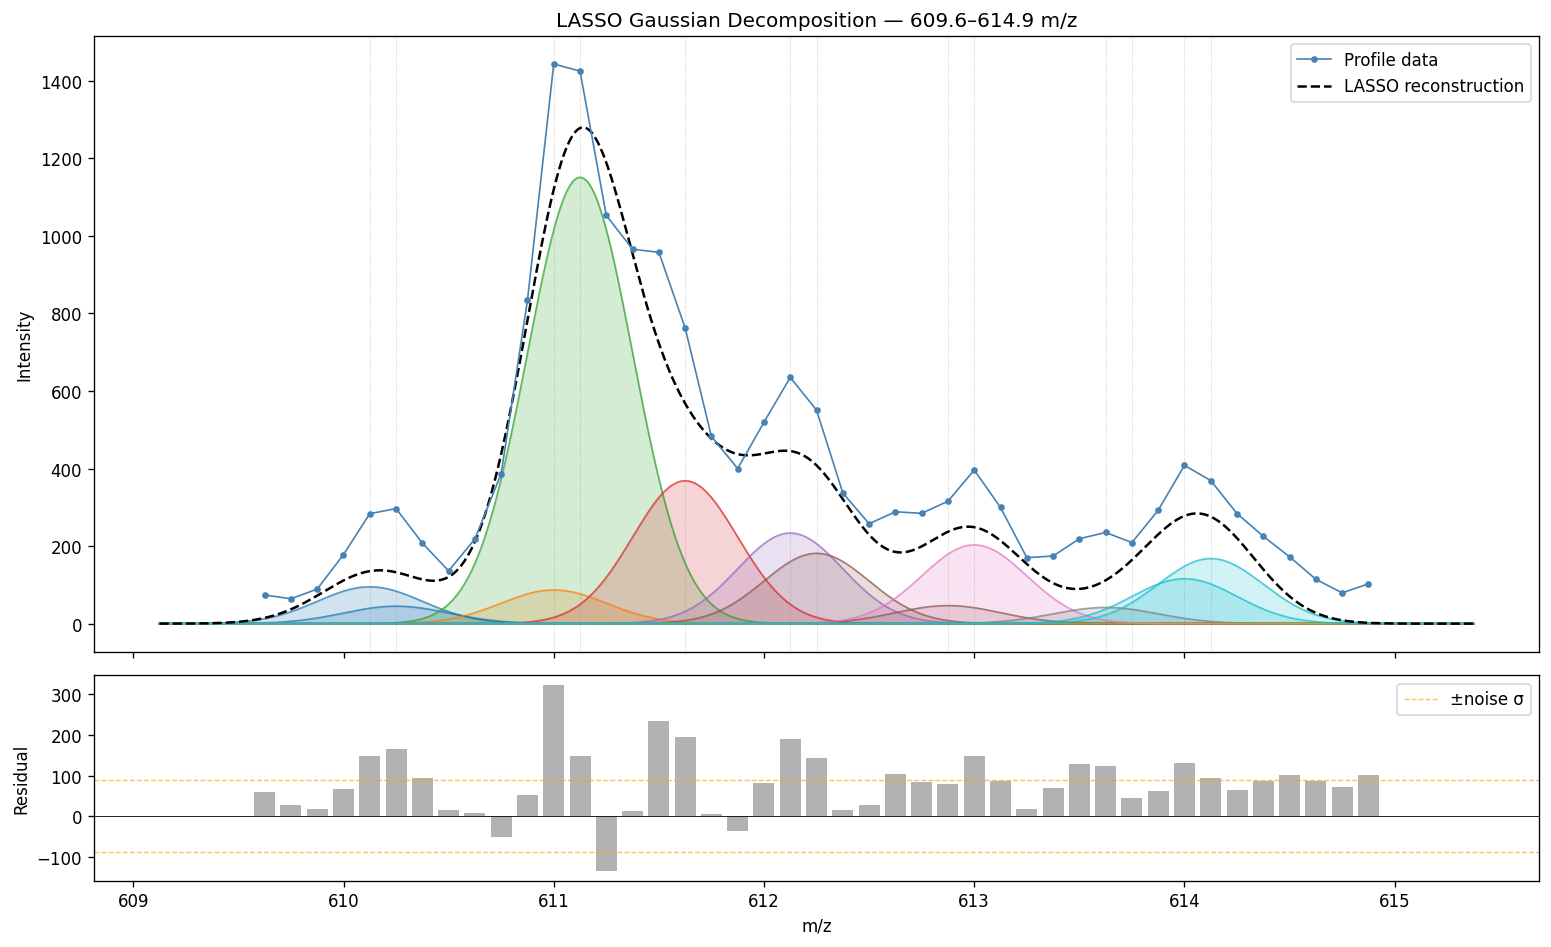

In [ ]:
# Dense m/z grid for smooth Gaussian curves
mz_dense = np.linspace(region_mz[0] - 0.5, region_mz[-1] + 0.5, 2000)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

# --- Top: Profile + individual Gaussian components + sum ---
ax = axes[0]
ax.plot(region_mz, region_int, "o-", color="steelblue", markersize=3, linewidth=1.0,
        label="Profile data", zorder=5)

# Sum of Gaussian components
reconstruction = np.zeros_like(mz_dense)
component_colors = plt.cm.tab10(np.linspace(0, 1, max(len(centroid_mz_lasso), 1)))

for idx, (cm, cb) in enumerate(zip(centroid_mz_lasso, centroid_int_lasso)):
    gauss = cb * np.exp(-0.5 * ((mz_dense - cm) / SIGMA) ** 2)
    reconstruction += gauss
    ax.fill_between(mz_dense, gauss, alpha=0.2, color=component_colors[idx])
    ax.plot(mz_dense, gauss, linewidth=1.0, color=component_colors[idx], alpha=0.7)

ax.plot(mz_dense, reconstruction, "k--", linewidth=1.5, label="LASSO reconstruction", zorder=4)

# Mark centroid positions
for cm, cb in zip(centroid_mz_lasso, centroid_int_lasso):
    ax.axvline(cm, color="gray", linestyle=":", linewidth=0.5, alpha=0.5)

ax.set_ylabel("Intensity")
ax.set_title(f"LASSO Gaussian Decomposition — {region_mz[0]:.1f}–{region_mz[-1]:.1f} m/z")
ax.legend(loc="upper right")

# --- Bottom: Residuals ---
ax = axes[1]
recon_at_data = np.zeros_like(region_mz, dtype=float)
for cm, cb in zip(centroid_mz_lasso, centroid_int_lasso):
    recon_at_data += cb * np.exp(-0.5 * ((region_mz - cm) / SIGMA) ** 2)

residuals = region_int - recon_at_data
ax.bar(region_mz, residuals, width=GRID_SPACING * 0.8, color="gray", alpha=0.6)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(noise_sigma, color="orange", linestyle="--", linewidth=0.8, alpha=0.7, label=f"±noise σ")
ax.axhline(-noise_sigma, color="orange", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_xlabel("m/z")
ax.set_ylabel("Residual")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 5. Head-to-Head: Centrix vs Thermo Centroids

Now let's directly compare the centroids from Centrix and Thermo across the full 540–620 m/z
window. Key things to look for:

- **Thermo** places ~1 centroid per Da, collapsing nearby signals
- **Centrix** resolves sub-Da peaks that Thermo merges together
- Where Thermo has one large centroid, Centrix may have two or more components

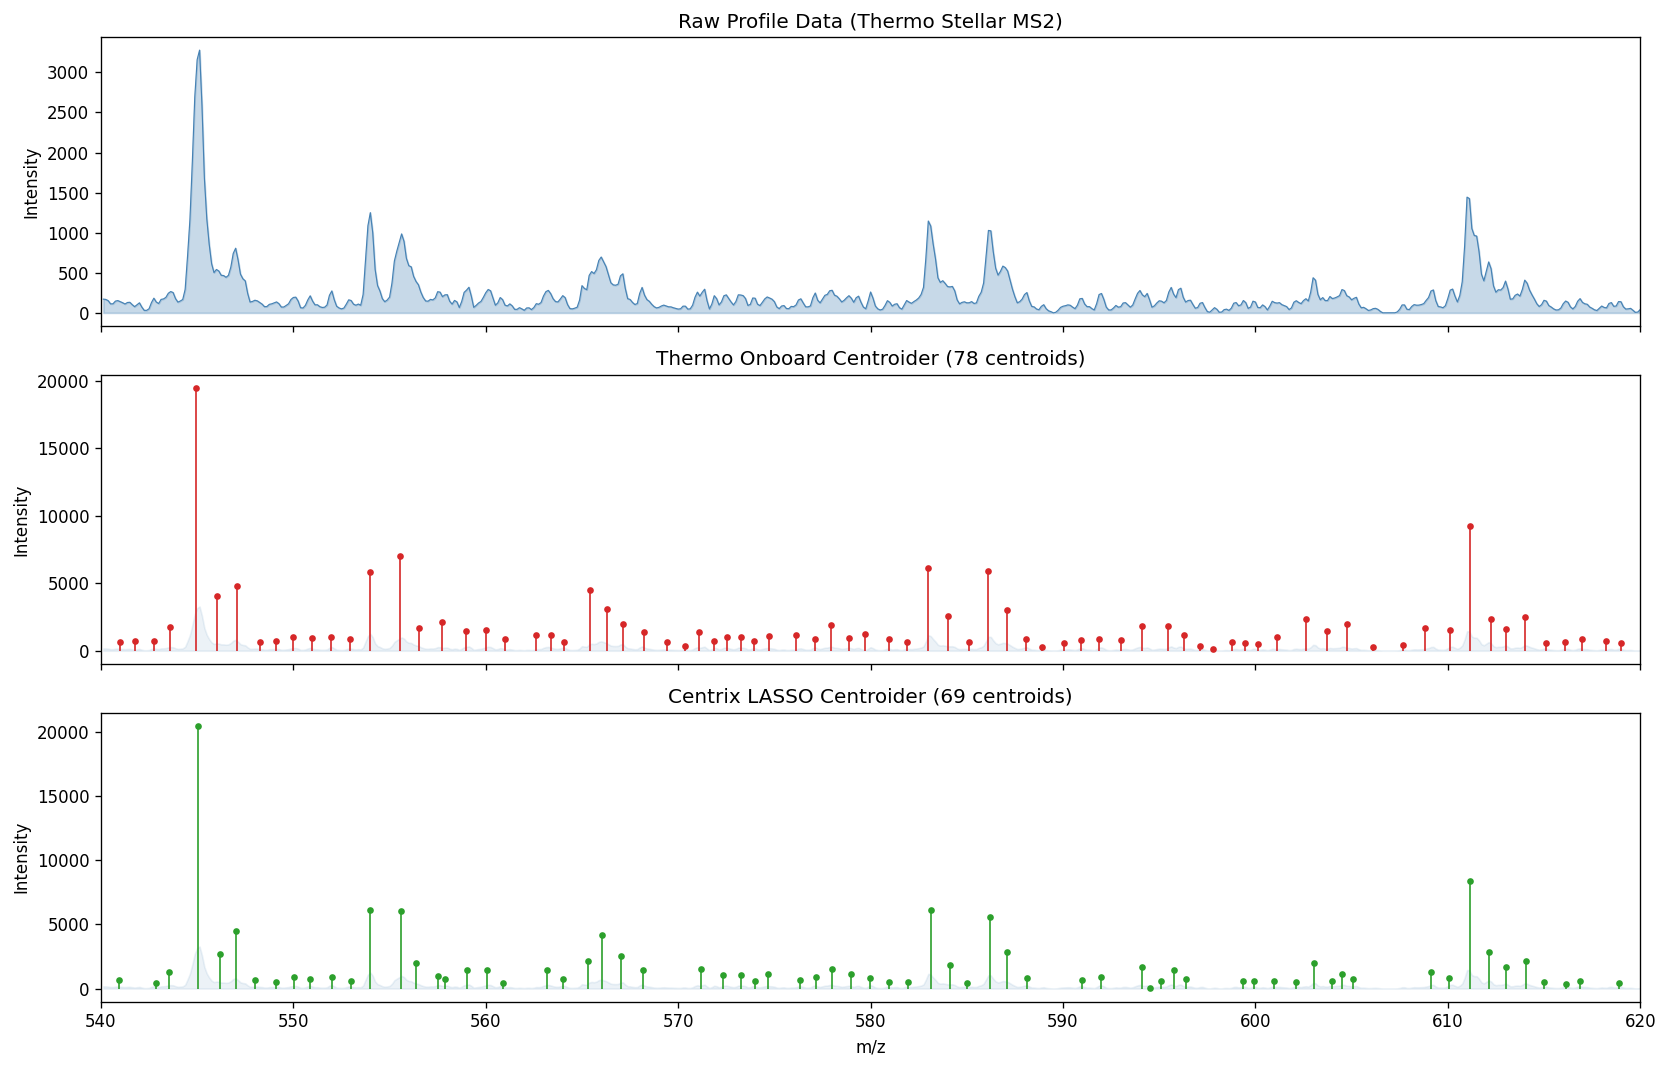


Centroid counts in 540.0–620.0 m/z:
  Thermo:    78
  Centrix:   69


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# --- Panel 1: Profile ---
ax = axes[0]
ax.fill_between(prof_mz_r, prof_int_r, alpha=0.3, color="steelblue")
ax.plot(prof_mz_r, prof_int_r, color="steelblue", linewidth=0.7)
ax.set_ylabel("Intensity")
ax.set_title("Raw Profile Data (Thermo Stellar MS2)")

# --- Panel 2: Thermo centroid sticks ---
ax = axes[1]
ax.fill_between(prof_mz_r, prof_int_r, alpha=0.1, color="steelblue")
markerline, stemlines, baseline = ax.stem(
    th_mz_r, th_int_r, linefmt="C3-", markerfmt="C3o", basefmt=" "
)
stemlines.set_linewidth(1.0)
markerline.set_markersize(3)
ax.set_ylabel("Intensity")
ax.set_title(f"Thermo Onboard Centroider ({len(th_mz_r)} centroids)")

# --- Panel 3: Centrix centroid sticks ---
ax = axes[2]
ax.fill_between(prof_mz_r, prof_int_r, alpha=0.1, color="steelblue")
markerline, stemlines, baseline = ax.stem(
    cx_mz_r, cx_int_r, linefmt="C2-", markerfmt="C2o", basefmt=" "
)
stemlines.set_linewidth(1.0)
markerline.set_markersize(3)
ax.set_ylabel("Intensity")
ax.set_xlabel("m/z")
ax.set_title(f"Centrix LASSO Centroider ({len(cx_mz_r)} centroids)")

for a in axes:
    a.set_xlim(MZ_LO, MZ_HI)

plt.tight_layout()
plt.show()

print(f"\nCentroid counts in {MZ_LO}–{MZ_HI} m/z:")
print(f"  Thermo:  {len(th_mz_r):>4}")
print(f"  Centrix: {len(cx_mz_r):>4}")

## 6. Detail Comparison — Selected Sub-Regions

Let's zoom into a few interesting sub-regions to highlight where Centrix disagrees with the
Thermo centroider and what the profile data actually shows.

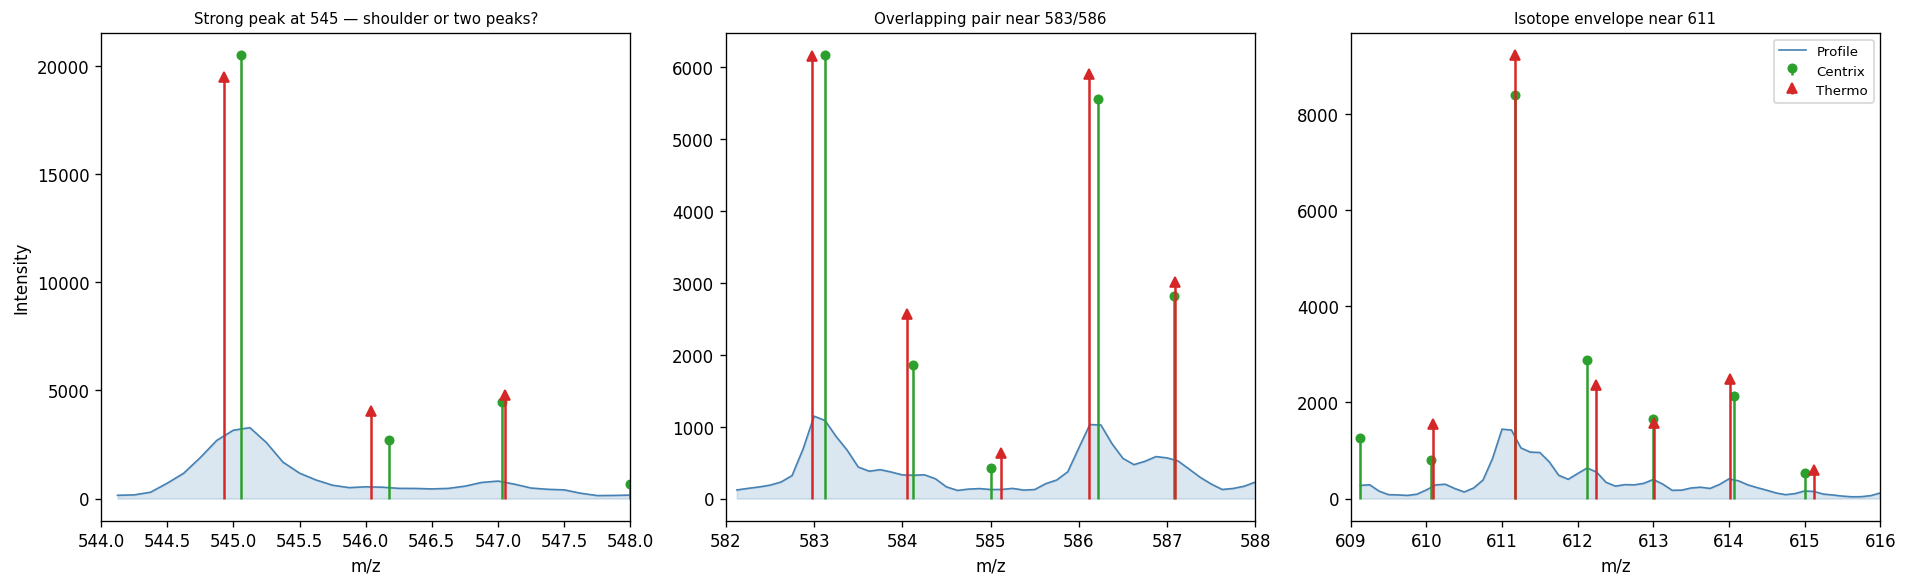

In [ ]:
zoom_regions = [
    (544, 548, "Strong peak at 545 — shoulder or two peaks?"),
    (582, 588, "Overlapping pair near 583/586"),
    (609, 616, "Isotope envelope near 611"),
]

fig, axes = plt.subplots(1, len(zoom_regions), figsize=(16, 5))

for ax, (lo, hi, title) in zip(axes, zoom_regions):
    pm, pi = crop(prof_mz, prof_int, lo, hi)
    cm, ci = crop(cx_mz,   cx_int,   lo, hi)
    tm, ti = crop(th_mz,   th_int,   lo, hi)

    # Profile fill
    ax.fill_between(pm, pi, alpha=0.2, color="steelblue")
    ax.plot(pm, pi, color="steelblue", linewidth=1.0, label="Profile")

    # Centrix stems
    ml, sl, bl = ax.stem(cm, ci, linefmt="C2-", markerfmt="C2o", basefmt=" ", label="Centrix")
    sl.set_linewidth(1.5); ml.set_markersize(5)

    # Thermo stems
    ml, sl, bl = ax.stem(tm, ti, linefmt="C3-", markerfmt="C3^", basefmt=" ", label="Thermo")
    sl.set_linewidth(1.5); ml.set_markersize(6)

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("m/z")
    ax.set_xlim(lo, hi)
    if ax == axes[0]:
        ax.set_ylabel("Intensity")

axes[-1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 7. LASSO Fit on Multiple Regions

Let's run the full LASSO decomposition on each signal region and overlay the fitted Gaussians
on the profile to show how Centrix reconstructs the entire 540–620 m/z window.

  Converged in 148 iterations (max_change=9.61e-07)
  Reached max iterations (1000), max_change=1.89e-01
  Converged in 18 iterations (max_change=0.00e+00)
  Converged in 12 iterations (max_change=0.00e+00)
  Converged in 7 iterations (max_change=0.00e+00)
  Converged in 14 iterations (max_change=0.00e+00)
  Converged in 8 iterations (max_change=0.00e+00)
  Reached max iterations (1000), max_change=1.99e-01
  Converged in 228 iterations (max_change=9.62e-07)
  Converged in 229 iterations (max_change=9.98e-07)
  Reached max iterations (1000), max_change=1.98e-01
  Converged in 126 iterations (max_change=9.68e-07)
  Converged in 264 iterations (max_change=9.78e-07)
  Converged in 116 iterations (max_change=9.59e-07)
  Converged in 124 iterations (max_change=9.28e-07)
  Reached max iterations (1000), max_change=7.88e-04
  Converged in 9 iterations (max_change=0.00e+00)
  Converged in 925 iterations (max_change=9.89e-07)
  Converged in 15 iterations (max_change=0.00e+00)
  Converged in 15 

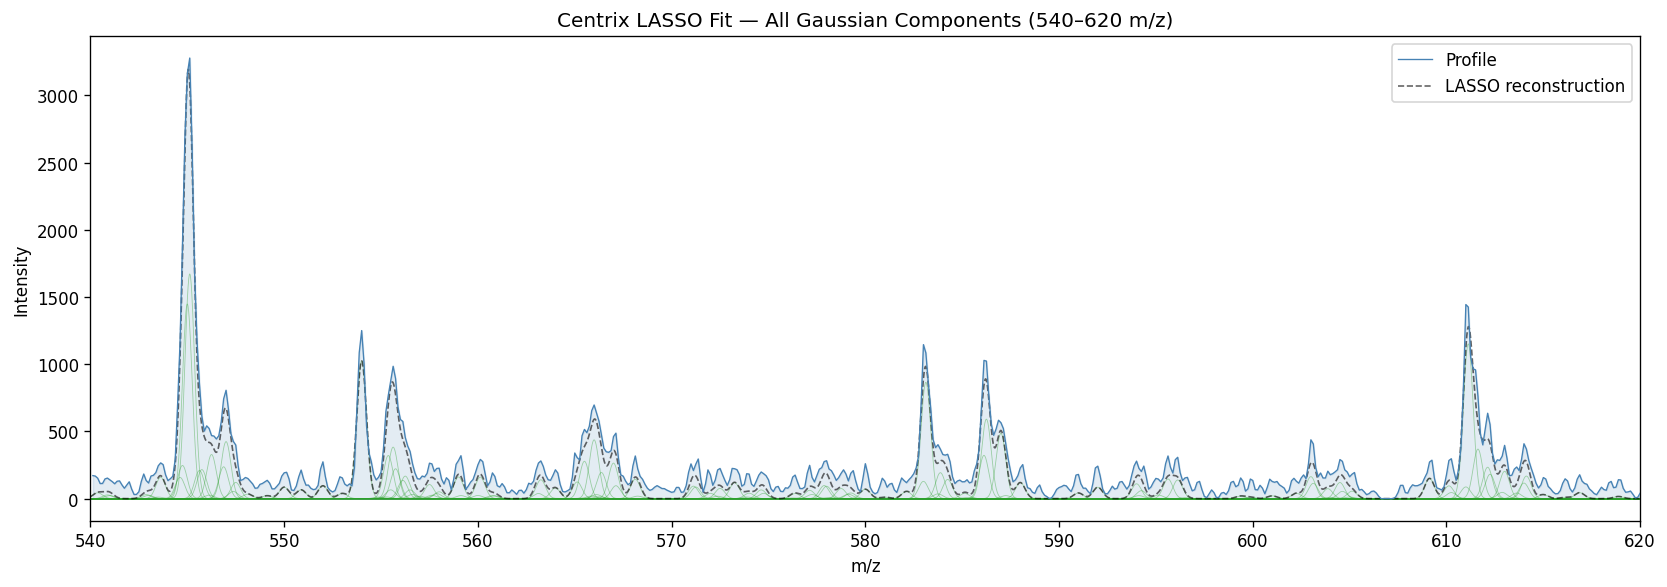

In [ ]:
# Run LASSO on all detected regions and collect centroids
all_centroids_mz = []
all_centroids_int = []
all_components = []  # (center, amplitude) for each Gaussian component

# Analytical Gram row (same as used in the single-region demo above)
norm = SIGMA * np.sqrt(np.pi) / GRID_SPACING
decay = -GRID_SPACING**2 / (4.0 * SIGMA**2)
gr = np.array([norm * np.exp(decay * k**2) for k in range(20)])
gr = gr[gr > norm * np.finfo(float).eps]

for s, e in regions:
    rmz = prof_mz_r[s:e]
    rint = prof_int_r[s:e]
    nb = len(rmz)

    # Build A matrix
    A_local = np.zeros((nb, nb))
    for j in range(nb):
        A_local[:, j] = np.exp(-0.5 * ((rmz - rmz[j]) / SIGMA) ** 2)

    # A^T y
    aty_local = A_local.T @ rint

    # Solve LASSO (silent)
    beta_local, _ = lasso_coordinate_descent(aty_local, gr, lam, nb, max_iter=1000, tol=1e-6)

    active = beta_local > 0
    for m, b in zip(rmz[active], beta_local[active]):
        all_centroids_mz.append(m)
        all_centroids_int.append(b)
        all_components.append((m, b))

all_centroids_mz = np.array(all_centroids_mz)
all_centroids_int = np.array(all_centroids_int)


# Scale to discrete-sum area for comparison with Centrix file output
# β × σ√(2π) / h  — matches Rust centroid.rs and Thermo convention
area_scale = SIGMA * np.sqrt(2 * np.pi) / GRID_SPACING
all_centroids_area = all_centroids_int * area_scale

print(f"Total LASSO centroids (Python): {len(all_centroids_mz)}")
print(f"Centrix centroids (from file):  {len(cx_mz_r)}")

# Plot: profile with all fitted Gaussian components
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(prof_mz_r, prof_int_r, alpha=0.15, color="steelblue")
ax.plot(prof_mz_r, prof_int_r, color="steelblue", linewidth=0.8, label="Profile", zorder=3)

# Overlay each Gaussian component
mz_smooth = np.linspace(MZ_LO, MZ_HI, 5000)
reconstruction = np.zeros_like(mz_smooth)
for cm, cb in all_components:
    g = cb * np.exp(-0.5 * ((mz_smooth - cm) / SIGMA) ** 2)
    reconstruction += g
    ax.plot(mz_smooth, g, linewidth=0.5, alpha=0.4, color="C2")

ax.plot(mz_smooth, reconstruction, "k--", linewidth=1.0, alpha=0.6, label="LASSO reconstruction")

ax.set_xlabel("m/z")
ax.set_ylabel("Intensity")
ax.set_title("Centrix LASSO Fit — All Gaussian Components (540–620 m/z)")
ax.legend(loc="upper right")
ax.set_xlim(MZ_LO, MZ_HI)
plt.tight_layout()
plt.show()

## 8. Summary Statistics

Let's compare the centroid count and m/z distribution between Thermo and Centrix across
this window.

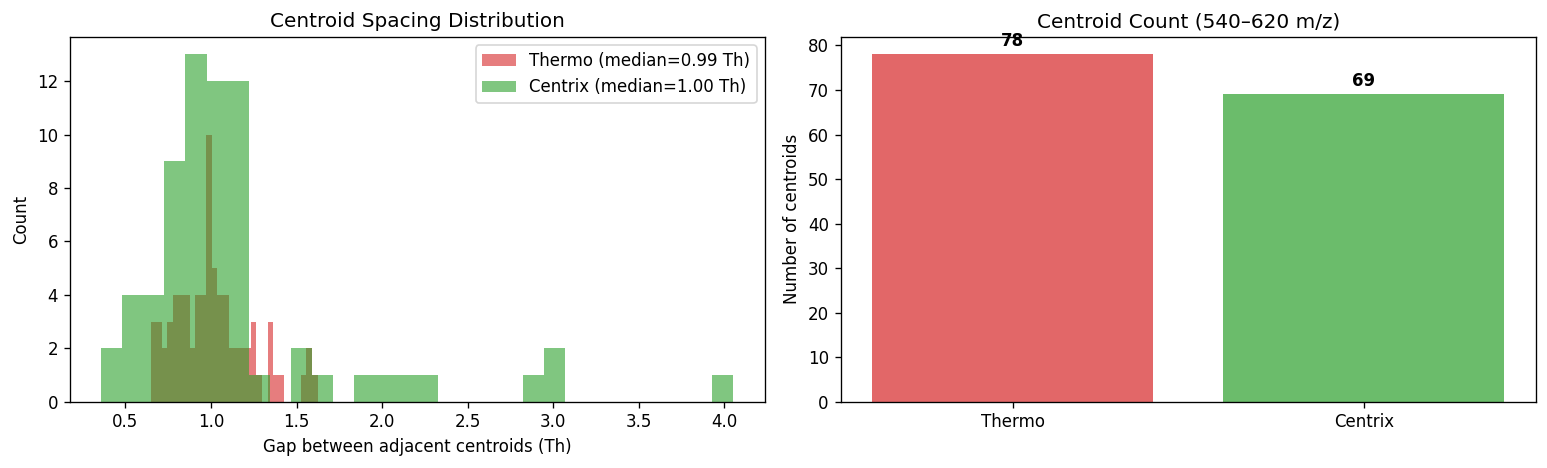


                         Thermo    Centrix
──────────────────────────────────────────
           Centroids         78         69
     Median gap (Th)      0.993      0.997
        Min gap (Th)      0.648      0.358
       Max intensity    19479.1    20508.1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: Centroid gap (nearest-neighbor distance) distributions ---
ax = axes[0]
if len(th_mz_r) > 1:
    th_gaps = np.diff(np.sort(th_mz_r))
    ax.hist(th_gaps, bins=30, alpha=0.6, color="C3", label=f"Thermo (median={np.median(th_gaps):.2f} Th)")
if len(cx_mz_r) > 1:
    cx_gaps = np.diff(np.sort(cx_mz_r))
    ax.hist(cx_gaps, bins=30, alpha=0.6, color="C2", label=f"Centrix (median={np.median(cx_gaps):.2f} Th)")
ax.set_xlabel("Gap between adjacent centroids (Th)")
ax.set_ylabel("Count")
ax.set_title("Centroid Spacing Distribution")
ax.legend()

# --- Right: Centroid count bar chart ---
ax = axes[1]
bars = ax.bar(["Thermo", "Centrix"], [len(th_mz_r), len(cx_mz_r)], color=["C3", "C2"], alpha=0.7)
ax.set_ylabel("Number of centroids")
ax.set_title(f"Centroid Count ({MZ_LO:.0f}–{MZ_HI:.0f} m/z)")
for bar, count in zip(bars, [len(th_mz_r), len(cx_mz_r)]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'':>20s} {'Thermo':>10s} {'Centrix':>10s}")
print(f"{'─' * 42}")
print(f"{'Centroids':>20s} {len(th_mz_r):>10d} {len(cx_mz_r):>10d}")
if len(th_mz_r) > 1 and len(cx_mz_r) > 1:
    print(f"{'Median gap (Th)':>20s} {np.median(th_gaps):>10.3f} {np.median(cx_gaps):>10.3f}")
    print(f"{'Min gap (Th)':>20s} {th_gaps.min():>10.3f} {cx_gaps.min():>10.3f}")
    print(f"{'Max intensity':>20s} {th_int_r.max():>10.1f} {cx_int_r.max():>10.1f}")